# Automation Risk and Employment in the US Labour Market

This project investigates which occupations face the highest risk of automation, and what
characteristics drive that risk, in order to support workforce planning decisions for
businesses and policymakers.

The analysis combines two real datasets: Frey & Osborne automation probability scores by
occupation, and the US Bureau of Labor Statistics (BLS) 2024–2034 employment projections.

The pipeline follows six stages: data integration, exploratory analysis, clustering of
occupations into types, regression to explain risk, classification to predict it, and an
ensemble model. Each stage is introduced in its own section below.

## 1. Data Loading and Integration

Two sources are combined. The automation dataset provides each occupation's probability of
automation and its employment level in every US state. The BLS dataset adds median wage,
projected employment growth, and typical entry education for each occupation.

The two are merged on the shared SOC occupation code, retaining the 607 occupations present
in both sources. This integration is necessary because automation risk alone is not
actionable; pairing it with wage, growth, and education turns it into a basis for decisions.

In [1]:
#Import libraries

# pandas handles tabular data (loading, merging, cleaning)
import pandas as pd
# numpy supports the numeric operations used later in modelling
import numpy as np
# matplotlib is the base plotting library for charts
import matplotlib.pyplot as plt
# seaborn builds on matplotlib for cleaner statistical visuals
import seaborn as sns

# show all columns when printing wide tables
pd.set_option("display.max_columns", None)
# widen output so rows are not truncated
pd.set_option("display.width", 200)

In [2]:
#Load the raw datasets

# automation file: occupation-level automation probability plus state employment counts
# encoding set to latin-1 because the file contains a non-UTF-8 character
auto = pd.read_csv(
    r"C:\Users\P. Moonnisa\Data analytics Project\IB94V0_Assignment\data\automation_data_by_state.csv",
    encoding="latin-1"
)

# BLS projections file: wages, employment growth and education by occupation
# header=1 because the real column names sit on the second row (row 0 is a title)
bls = pd.read_excel(
    r"C:\Users\P. Moonnisa\Data analytics Project\IB94V0_Assignment\data\Data_BLS\bls_employment_projections.xlsx",
    sheet_name="Table 1.2",
    header=1
)

# inspect the shape of each raw table before combining
print("Automation file:", auto.shape)
print("BLS file:", bls.shape)

Automation file: (702, 54)
BLS file: (1117, 16)


In [3]:
#Merge automation data with BLS labour data

# rename BLS columns to short, consistent names
bls = bls.rename(columns={
    "2024 National Employment Matrix code": "SOC",                 # occupation code (shared key)
    "Employment, 2024": "Emp_2024",                                # current employment level
    "Employment, 2034": "Emp_2034",                                # projected employment level
    "Employment change, percent, 2024–34": "Emp_Change_Pct",       # projected % growth or decline
    "Median annual wage, dollars, 2024[1]": "Median_Wage",         # typical pay for the occupation
    "Typical education needed for entry": "Education",             # entry education requirement
    "Typical on-the-job training needed to attain competency in the occupation": "Training"  # training requirement
})

# keep only the BLS fields used as predictors
bls = bls[["SOC", "Emp_2024", "Emp_2034", "Emp_Change_Pct", "Median_Wage", "Education", "Training"]]

# SOC is the common occupation code; standardise it on both tables so keys match exactly
auto["SOC"] = auto["SOC"].astype(str).str.strip()
bls["SOC"] = bls["SOC"].astype(str).str.strip()

# inner merge keeps only occupations present in both sources (607 of 702)
df = auto.merge(bls, on="SOC", how="inner")

# convert numeric fields; BLS placeholder dashes become missing values
for col in ["Emp_2024", "Emp_2034", "Emp_Change_Pct", "Median_Wage"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# confirm the merged master table
print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (607, 60)


,SOC,Occupation,Probability,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,District of Columbia,Florida,Georgia,Hawaii,Idaho,Illinois,Indiana,Iowa,Kansas,Kentucky,Louisiana,Maine,Maryland,Massachusetts,Michigan,Minnesota,Mississippi,Missouri,Montana,Nebraska,Nevada,New Hampshire,New Jersey,New Mexico,New York,North Carolina,North Dakota,Ohio,Oklahoma,Oregon,Pennsylvania,Rhode Island,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming,Emp_2024,Emp_2034,Emp_Change_Pct,Median_Wage,Education,Training
0,11-1011,Chief Executives,0.015,1030,760,5750,2710,31150,880,1410,340,2840,14120,6750,1840,1400,17440,4950,2050,4410,3440,1010,920,1800,11020,6260,7490,940,5180,600,690,1410,940,700,70,15410,4310,920,5340,6370,2650,9230,390,3400,560,5460,5890,3650,280,6320,5910,980,3740,160,309.4,322.7,4.3,206420.0,Bachelor's degree,NaN
1,11-1021,General and Operations Managers,0.160,26930,6490,43300,20680,261780,41540,33280,4080,26610,77340,90520,11070,12250,121040,49210,25900,19620,26190,29920,12360,47850,71880,58040,41480,24110,41440,4490,14420,17480,11030,44800,15550,162870,53770,7010,64710,27400,32350,70430,6640,31780,3730,44400,168610,36200,2760,52380,43760,10200,32350,4840,3712.9,3876.8,4.4,102950.0,Bachelor's degree,NaN
2,11-2011,Advertising and Promotions Managers,0.039,50,40,470,110,3760,480,300,0,220,750,820,200,160,3670,290,230,230,270,320,130,460,1290,650,610,150,390,30,80,280,150,630,190,5130,450,70,460,200,0,570,100,270,0,670,1210,380,40,240,640,40,200,0,27.0,26.4,-2.2,126960.0,Bachelor's degree,NaN
3,11-2021,Marketing Managers,0.014,530,200,4790,1090,33390,3060,4970,590,1280,7600,7140,540,860,14030,2870,1920,1470,1490,920,810,2980,11790,3870,7800,470,2590,130,1060,1640,1170,11260,350,16500,5650,310,5350,1420,4830,6250,550,1710,60,3400,9570,2320,380,3840,5830,260,2980,30,407.0,433.7,6.6,161030.0,Bachelor's degree,NaN
4,11-2022,Sales Managers,0.013,2510,400,10650,2650,69180,4570,7040,860,1180,13560,15460,2470,2200,24150,5770,3350,3250,3420,3560,980,5230,14860,10090,12590,1460,5480,190,1930,3350,1750,12840,1200,20170,6750,710,11410,3890,6220,8930,850,3540,300,8890,22310,3360,480,5360,7390,600,5730,180,619.5,648.5,4.7,138060.0,Bachelor's degree,NaN


## 2. Exploratory Data Analysis

This section examines the structure of the data before modelling. It creates a national
employment total per occupation, checks data types and missing values, and explores how
automation risk relates to wage, projected growth, and education.

The aim is to identify the main patterns and justify the modelling choices that follow. A
key expected finding is whether automation risk is concentrated in particular kinds of jobs.

In [4]:
#Create total employment feature

# the 51 state columns sit between 'Probability' and 'Emp_2024'
state_cols = list(df.columns[3:54])

# sum employment across all states to get one national total per occupation
df["Total_Emp"] = df[state_cols].sum(axis=1)

# preview the new feature against automation risk
df[["Occupation", "Probability", "Total_Emp", "Median_Wage"]].head()

,Occupation,Probability,Total_Emp,Median_Wage
0,Chief Executives,0.015,223270,206420.0
1,General and Operations Managers,0.160,2188870,102950.0
2,Advertising and Promotions Managers,0.039,28080,126960.0
3,Marketing Managers,0.014,205900,161030.0
4,Sales Managers,0.013,365250,138060.0


In [5]:
#Inspect structure and data types

# row and column counts of the master table
print("Shape:", df.shape)

# column names, non-null counts and data types
df.info()

Shape: (607, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 61 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SOC                   607 non-null    object 
 1   Occupation            607 non-null    object 
 2   Probability           607 non-null    float64
 3   Alabama               607 non-null    int64  
 4   Alaska                607 non-null    int64  
 5   Arizona               607 non-null    int64  
 6   Arkansas              607 non-null    int64  
 7   California            607 non-null    int64  
 8   Colorado              607 non-null    int64  
 9   Connecticut           607 non-null    int64  
 10  Delaware              607 non-null    int64  
 11  District of Columbia  607 non-null    int64  
 12  Florida               607 non-null    int64  
 13  Georgia               607 non-null    int64  
 14  Hawaii                607 non-null    int64  
 15  Idaho 

In [6]:
#Check missing values

# count missing entries per column, showing only affected columns
missing = df.isnull().sum()
print(missing[missing > 0])

# Median_Wage missing for 6 occupations; Training missing for 198 (handled before modelling)

Median_Wage      6
Training       198
dtype: int64


In [7]:
#Summary statistics for the key numeric variables

# describe the target and the main numeric predictors
df[["Probability", "Median_Wage", "Emp_Change_Pct", "Total_Emp"]].describe()

,Probability,Median_Wage,Emp_Change_Pct,Total_Emp
count,607.000000,601.000000,607.000000,6.070000e+02
mean,0.540724,64835.207987,0.918451,1.759928e+05
std,0.370610,29231.142896,7.342317,4.118413e+05
min,0.002800,30160.000000,-36.100000,0.000000e+00
25%,0.105000,45650.000000,-2.200000,1.550500e+04
50%,0.650000,57250.000000,2.300000,4.570000e+04
75%,0.890000,77020.000000,4.600000,1.403150e+05
max,0.990000,226600.000000,23.200000,4.528570e+06


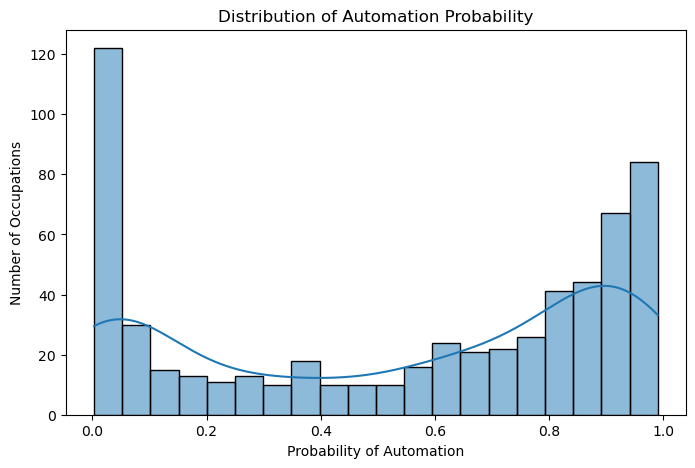

In [8]:
#Distribution of the automation probability (target)

# histogram shows how automation risk is spread across occupations
plt.figure(figsize=(8, 5))
sns.histplot(df["Probability"], bins=20, kde=True)
plt.title("Distribution of Automation Probability")
plt.xlabel("Probability of Automation")
plt.ylabel("Number of Occupations")
plt.show()

# the spread is bimodal: many low-risk and many high-risk occupations

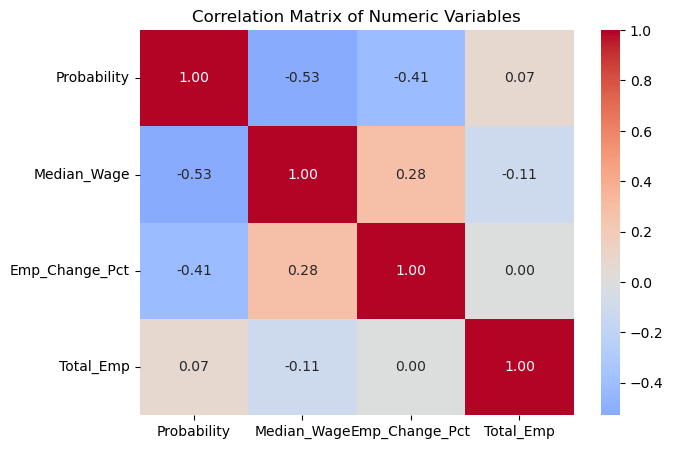

In [9]:
#Correlation between numeric variables

# correlation matrix quantifies linear relationships among numeric fields
num_cols = ["Probability", "Median_Wage", "Emp_Change_Pct", "Total_Emp"]
corr = df[num_cols].corr()

# heatmap makes the correlations easy to read
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

# automation risk falls as wages and projected growth rise

Education
No formal educational credential     0.787375
Some college, no degree              0.767500
High school diploma or equivalent    0.716494
Postsecondary nondegree award        0.496200
—                                    0.451000
Associate's degree                   0.429325
Bachelor's degree                    0.199561
Doctoral or professional degree      0.104705
Master's degree                      0.100396
Name: Probability, dtype: float64


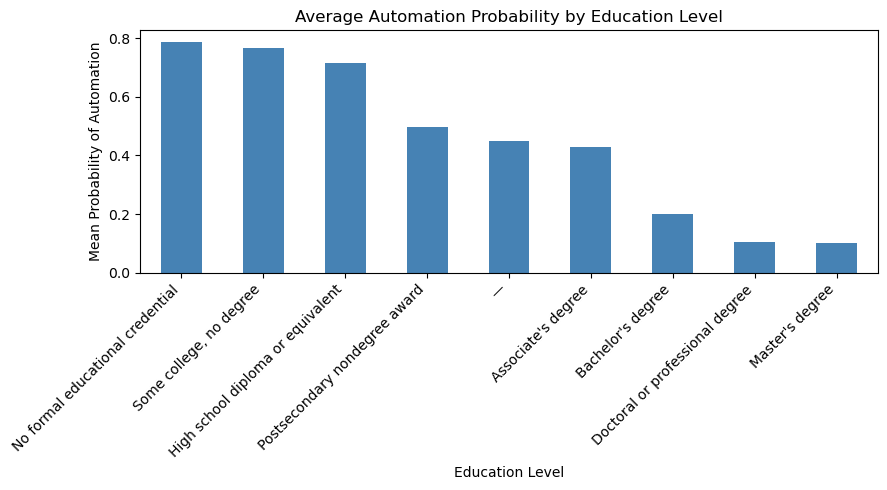

In [10]:
#Automation risk by education level

# average automation probability grouped by entry education requirement
edu_risk = df.groupby("Education")["Probability"].mean().sort_values(ascending=False)
print(edu_risk)

# bar chart visualises the pattern across education levels
plt.figure(figsize=(9, 5))
edu_risk.plot(kind="bar", color="steelblue")
plt.title("Average Automation Probability by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Mean Probability of Automation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# automation risk is highest where entry education requirements are lowest

## 3. Clustering Occupations into Types

Clustering groups the 607 occupations into distinct types based on their characteristics, allowing the labour market to be understood as a small number of segments rather than hundreds of individual jobs.

Occupations are clustered on wage, projected growth, and employment size only. Automation risk is deliberately excluded from the clustering so that any difference in risk between clusters is a genuine result rather than a built-in artefact. The cluster label is retained as a predictor in the regression that follows.

In [11]:
#Prepare features for clustering

from sklearn.preprocessing import StandardScaler

# fill the 6 missing wages with the median so all occupations are retained
df["Median_Wage"] = df["Median_Wage"].fillna(df["Median_Wage"].median())

# cluster on job CHARACTERISTICS only, not on automation risk, to avoid leakage downstream
cluster_features = df[["Median_Wage", "Emp_Change_Pct", "Total_Emp"]].copy()

# standardise so variables on different scales contribute equally to distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

C:\Users\P. Moonnisa\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\P. Moonnisa\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\P. Moonnisa\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\P. Moonnisa\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

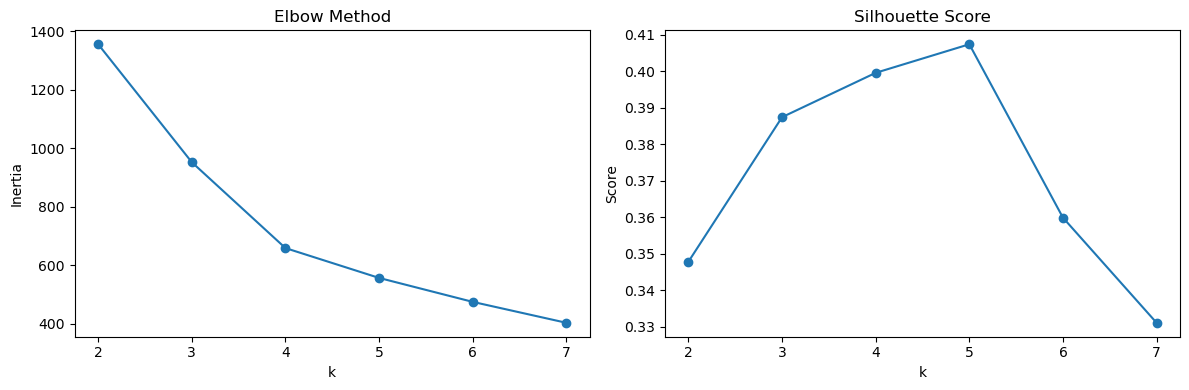

In [12]:
#Choose the number of clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# test a range of k using inertia (elbow) and silhouette (separation quality)
inertias, silhouettes, k_range = [], [], range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# plot both diagnostics side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_range, inertias, "o-"); ax[0].set_title("Elbow Method"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(k_range, silhouettes, "o-"); ax[1].set_title("Silhouette Score"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Score")
plt.tight_layout(); plt.show()

# k=4 balances a clear elbow with a strong silhouette score

In [13]:
#Fit the final clustering model

# fit KMeans with the chosen four clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# attach each occupation's cluster label to the master table for use as a later predictor
df["Cluster"] = kmeans.fit_predict(X_scaled)

# count occupations per cluster
print(df["Cluster"].value_counts().sort_index())

Cluster
0    365
1     19
2    107
3    116
Name: count, dtype: int64


C:\Users\P. Moonnisa\ANACONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [14]:
#Profile the clusters

# average each variable per cluster to characterise the occupation types
cluster_profile = df.groupby("Cluster").agg(
    Occupations=("Probability", "size"),
    Mean_Automation_Risk=("Probability", "mean"),
    Mean_Wage=("Median_Wage", "mean"),
    Mean_Growth=("Emp_Change_Pct", "mean"),
    Mean_Employment=("Total_Emp", "mean")
).round(2)

# automation risk was not used to build the clusters, so its variation here is a genuine result
cluster_profile

,Occupations,Mean_Automation_Risk,Mean_Wage,Mean_Growth,Mean_Employment
Cluster,,,,,
0,365,0.55,55435.97,3.34,130456.85
1,19,0.70,50780.53,-0.11,2059785.79
2,107,0.18,115617.66,5.06,97082.34
3,116,0.81,49477.67,-10.35,83509.57


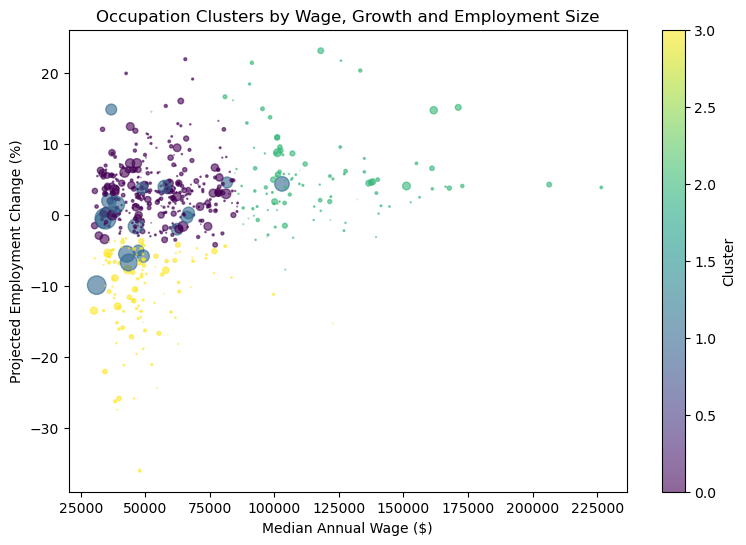

In [15]:
#Visualise the clusters

# scatter wage against projected growth, coloured by cluster, sized by employment
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df["Median_Wage"], df["Emp_Change_Pct"],
                      c=df["Cluster"], cmap="viridis",
                      s=df["Total_Emp"] / 20000, alpha=0.6)
plt.title("Occupation Clusters by Wage, Growth and Employment Size")
plt.xlabel("Median Annual Wage ($)")
plt.ylabel("Projected Employment Change (%)")
plt.colorbar(scatter, label="Cluster")
plt.show()

# distinct occupation types separate clearly on pay and growth trajectory

## 4. Regression: Explaining Automation Risk

This section quantifies how strongly wage, projected growth, employment size, education, and cluster membership relate to automation risk.

Continuous predictors are standardised so their effects are directly comparable, employment is log-transformed to reduce skew, and education is encoded as an ordinal scale. An Education × Wage interaction is included, selected because it was the only statistically significant interaction among those tested. Multicollinearity is checked using VIF before the model is interpreted.

In [16]:
#Prepare data for regression

# convert education text into an ordinal scale (0 = lowest, 7 = highest)
edu_order = {
    "No formal educational credential": 0,
    "High school diploma or equivalent": 1,
    "Some college, no degree": 2,
    "Postsecondary nondegree award": 3,
    "Associate's degree": 4,
    "Bachelor's degree": 5,
    "Master's degree": 6,
    "Doctoral or professional degree": 7
}
df["Edu_Level"] = df["Education"].map(edu_order)

# drop the 2 occupations with an unknown education placeholder
reg = df.dropna(subset=["Edu_Level"]).copy()

# log-transform employment to reduce its heavy skew
reg["Log_Emp"] = np.log1p(reg["Total_Emp"])

# standardise continuous predictors so coefficients are comparable in scale
for col in ["Median_Wage", "Emp_Change_Pct", "Log_Emp", "Edu_Level"]:
    reg[col + "_z"] = (reg[col] - reg[col].mean()) / reg[col].std()

# interaction term: does the effect of wage depend on education level?
reg["Edu_x_Wage"] = reg["Edu_Level_z"] * reg["Median_Wage_z"]

# turn the 4 clusters into dummy variables (cluster 0 is the baseline)
cluster_dummies = pd.get_dummies(reg["Cluster"], prefix="Clu", drop_first=True).astype(float)

# assemble the predictor matrix
X = pd.concat([
    reg[["Median_Wage_z", "Emp_Change_Pct_z", "Log_Emp_z", "Edu_Level_z", "Edu_x_Wage"]],
    cluster_dummies
], axis=1)

# target variable: automation probability
y = reg["Probability"]

In [17]:
#Check multicollinearity with VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF measures how much each predictor overlaps with the others
# values below 5 indicate multicollinearity is not a concern
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif.round(2))

           Variable   VIF
0     Median_Wage_z  3.32
1  Emp_Change_Pct_z  2.17
2         Log_Emp_z  1.21
3       Edu_Level_z  1.81
4        Edu_x_Wage  2.30
5             Clu_1  1.20
6             Clu_2  3.22
7             Clu_3  2.33


In [18]:
#Fit the regression model

import statsmodels.api as sm

# add a constant (intercept) term to the predictors
X_const = sm.add_constant(X)

# fit ordinary least squares regression of automation risk on all predictors
model = sm.OLS(y, X_const).fit()

# full statistical summary: coefficients, significance, R-squared
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Probability   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     77.77
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           1.86e-87
Time:                        17:09:51   Log-Likelihood:                -40.856
No. Observations:                 605   AIC:                             99.71
Df Residuals:                     596   BIC:                             139.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.5256      0.017  

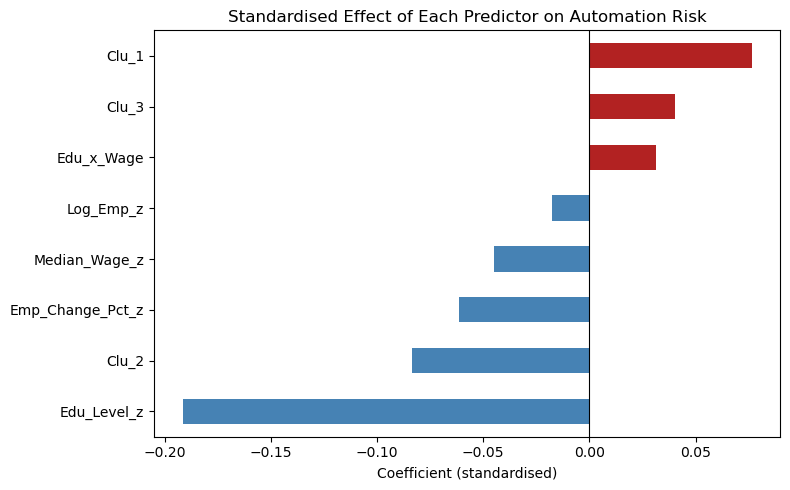

In [19]:
#Visualise predictor effects

# extract coefficients (excluding the intercept) to compare their direction and size
coefs = model.params.drop("const").sort_values()

# horizontal bar chart of standardised effects on automation risk
plt.figure(figsize=(8, 5))
coefs.plot(kind="barh", color=["firebrick" if c > 0 else "steelblue" for c in coefs])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Standardised Effect of Each Predictor on Automation Risk")
plt.xlabel("Coefficient (standardised)")
plt.tight_layout()
plt.show()

# negative bars reduce automation risk; education has the strongest protective effect

## 5. Classification: Predicting High-Risk Occupations

This section reframes automation risk as a binary decision: each occupation is labelled high-risk if its automation probability is 0.5 or above, the natural "more likely than not" threshold.

Two classifiers are trained and compared: a decision tree, chosen for its interpretable decision rules, and logistic regression, a stable statistical benchmark. Models are trained on 75% of the data and evaluated on a held-out 25% test set, using accuracy, precision, and recall to account for the mild class imbalance.

In [20]:
#Create the binary target

# label an occupation high-risk (1) if automation probability is 0.5 or above, else low-risk (0)
df["High_Risk"] = (df["Probability"] >= 0.5).astype(int)

# check how many occupations fall into each class
print(df["High_Risk"].value_counts())

High_Risk
1    355
0    252
Name: count, dtype: int64


In [21]:
#Build features and split into train/test sets

from sklearn.model_selection import train_test_split

# log-transform employment for a consistent feature scale
df["Log_Emp"] = np.log1p(df["Total_Emp"])

# drop the 2 occupations with unknown education
data = df.dropna(subset=["Edu_Level"]).copy()

# predictors: job characteristics plus cluster membership (Probability excluded to avoid leakage)
features = ["Median_Wage", "Emp_Change_Pct", "Log_Emp", "Edu_Level"]
X = data[features].copy()

# add cluster dummies (cluster 0 as baseline)
cluster_dummies = pd.get_dummies(data["Cluster"], prefix="Clu", drop_first=True).astype(float)
X = pd.concat([X, cluster_dummies], axis=1)

# standardise continuous features (needed for logistic regression, harmless for the tree)
for col in features:
    X[col] = (X[col] - X[col].mean()) / X[col].std()

# target variable
y = data["High_Risk"]

# 75/25 split; stratify keeps the class balance equal in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set:", X_train.shape[0], "| Test set:", X_test.shape[0])

Training set: 453 | Test set: 152


Decision Tree
Accuracy : 0.776
Precision: 0.778
Recall   : 0.865


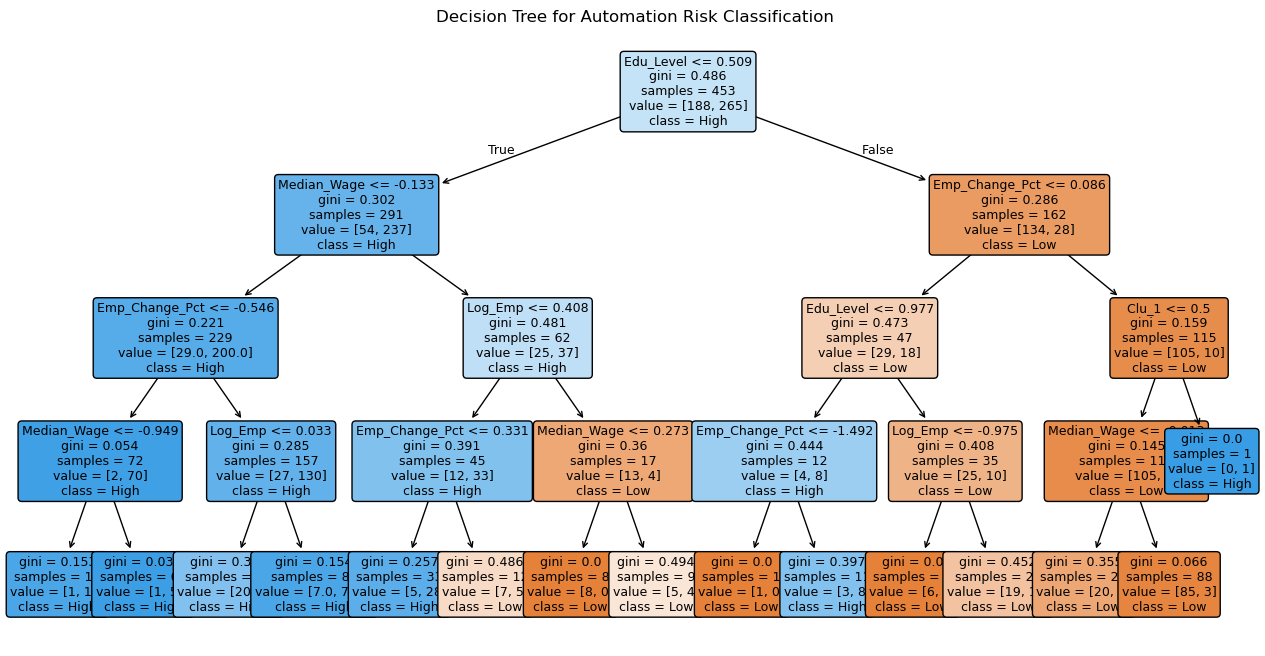

In [22]:
#Decision tree classifier

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# limit depth to 4 to keep the tree readable and prevent overfitting
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

# predict on the unseen test set
tree_pred = tree.predict(X_test)

# evaluate
print("Decision Tree")
print("Accuracy :", round(accuracy_score(y_test, tree_pred), 3))
print("Precision:", round(precision_score(y_test, tree_pred), 3))
print("Recall   :", round(recall_score(y_test, tree_pred), 3))

# visualise the decision rules
plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=X.columns, class_names=["Low", "High"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree for Automation Risk Classification")
plt.show()

In [23]:
#Logistic regression classifier

from sklearn.linear_model import LogisticRegression

# fit logistic regression as a stable statistical benchmark
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

# predict on the unseen test set
logit_pred = logit.predict(X_test)

# evaluate
print("Logistic Regression")
print("Accuracy :", round(accuracy_score(y_test, logit_pred), 3))
print("Precision:", round(precision_score(y_test, logit_pred), 3))
print("Recall   :", round(recall_score(y_test, logit_pred), 3))

Logistic Regression
Accuracy : 0.796
Precision: 0.784
Recall   : 0.899


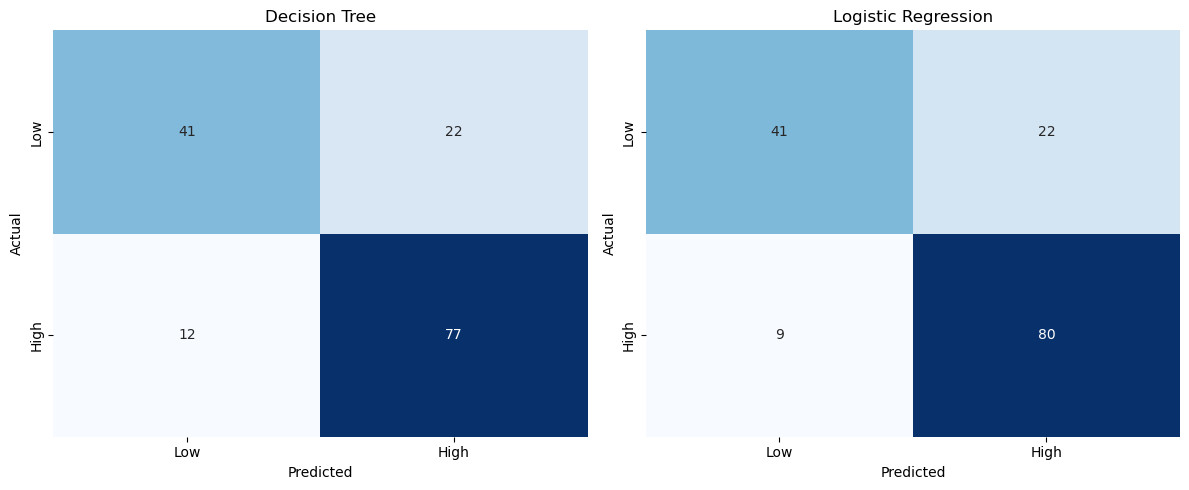

In [24]:
#Compare the two classifiers

import seaborn as sns

# plot both confusion matrices side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for axis, pred, name in zip(ax, [tree_pred, logit_pred], ["Decision Tree", "Logistic Regression"]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Low", "High"], yticklabels=["Low", "High"], ax=axis)
    axis.set_title(name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# logistic regression slightly outperforms the tree, but the tree offers clearer rules

## 6. Ensemble Model: Combining Classifiers by Voting

This section combines the individual classifiers into a voting ensemble, testing whether
pooling their predictions improves on any single model.

Three diverse base learners are used: a decision tree, logistic regression, and K-Nearest Neighbours. Two voting strategies are compared: hard voting, which takes the majority predicted label, and soft voting, which averages predicted probabilities and so gives more weight to confident predictions.

In [25]:
#Build the base learners and voting ensembles

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

# three diverse base classifiers (an odd number avoids tied votes)
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
logit_clf = LogisticRegression(max_iter=1000)
knn_clf = KNeighborsClassifier(n_neighbors=7)

# hard voting: predict the majority class label across the three models
vote_hard = VotingClassifier(
    estimators=[("tree", tree_clf), ("logit", logit_clf), ("knn", knn_clf)],
    voting="hard"
)

# soft voting: average the predicted probabilities, favouring confident predictions
vote_soft = VotingClassifier(
    estimators=[("tree", tree_clf), ("logit", logit_clf), ("knn", knn_clf)],
    voting="soft"
)

In [26]:
#Train and evaluate all models

# collect every model to compare base learners against the ensembles
all_models = {
    "Decision Tree": tree_clf,
    "Logistic Regression": logit_clf,
    "KNN": knn_clf,
    "Voting (hard)": vote_hard,
    "Voting (soft)": vote_soft
}

# train each model and record its test-set metrics
results = []
for name, model in all_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, pred), 3),
        "Precision": round(precision_score(y_test, pred), 3),
        "Recall": round(recall_score(y_test, pred), 3)
    })

# present the comparison as a table
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall
0        Decision Tree     0.776      0.778   0.865
1  Logistic Regression     0.796      0.784   0.899
2                  KNN     0.796      0.796   0.876
3        Voting (hard)     0.796      0.790   0.888
4        Voting (soft)     0.776      0.767   0.888


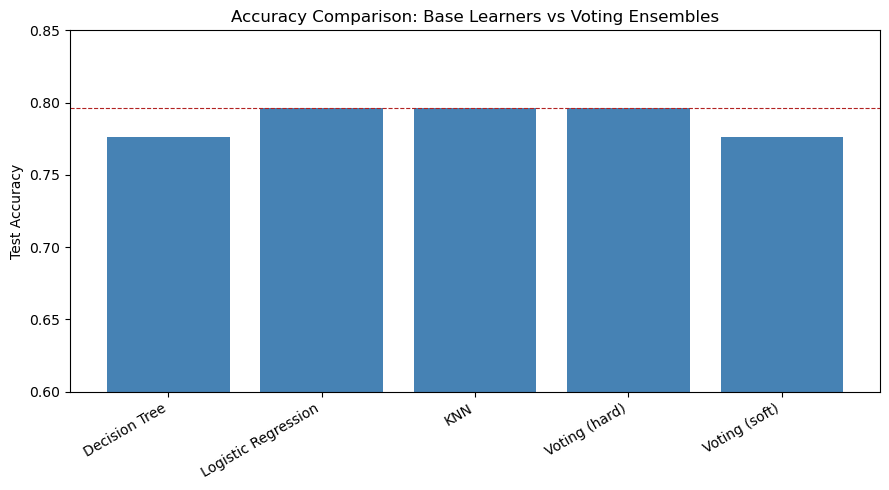

In [27]:
#Visualise the model comparison

# bar chart comparing accuracy across all models
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"], color="steelblue")
plt.ylim(0.6, 0.85)
plt.title("Accuracy Comparison: Base Learners vs Voting Ensembles")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=30, ha="right")
plt.axhline(results_df["Accuracy"].max(), color="firebrick", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. Identifying the Occupations Most and Least at Risk

This final step translates the analysis into concrete terms by listing the specific occupations at highest and lowest risk, and the high-risk occupations employing the most workers. This distinguishes intensity of risk (highest probability) from scale of impact (most workers affected), which matter to different stakeholders.

In [28]:
#Identify the occupations most and least at risk

# highest-risk occupations by automation probability
top_risk = df.nlargest(12, "Probability")[
    ["Occupation", "Probability", "Median_Wage", "Emp_Change_Pct", "Total_Emp"]
]
print("Highest-risk occupations (by probability):")
print(top_risk.to_string(index=False))
print()

# lowest-risk occupations by automation probability
low_risk = df.nsmallest(10, "Probability")[
    ["Occupation", "Probability", "Median_Wage", "Total_Emp"]
]
print("Lowest-risk occupations (by probability):")
print(low_risk.to_string(index=False))
print()

# high-risk occupations ranked by number of workers affected (scale of impact)
mass_risk = df[df["Probability"] > 0.6].nlargest(10, "Total_Emp")[
    ["Occupation", "Probability", "Total_Emp", "Median_Wage"]
]
print("High-risk occupations employing the most workers:")
print(mass_risk.to_string(index=False))

Highest-risk occupations (by probability):
                                                   Occupation  Probability  Median_Wage  Emp_Change_Pct  Total_Emp
                                       Insurance Underwriters         0.99      79880.0            -2.6      90310
                                                Tax Preparers         0.99      50560.0             4.5      63600
                  Title Examiners; Abstractors; and Searchers         0.99      54980.0             2.0      51810
                                          Library Technicians         0.99      39970.0            -6.8      93400
                                                Telemarketers         0.99      34410.0           -22.1     214570
                                          New Accounts Clerks         0.99      46610.0           -13.2      41430
                                     Cargo and Freight Agents         0.99      49900.0             8.5      88910
                                     